In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import stable_retro
import matplotlib.pyplot as plt
import numpy as np
from gymnasium.wrappers import RecordVideo
import gymnasium as gym
import os
import cv2
from collections import deque
from datetime import datetime


#### Mario Environment and Rewards

In [ ]:
def compute_reward(prev_info, curr_info, done):
    reward = 0.0

    if curr_info.get('midpoint_flag', 0) > prev_info.get('midpoint_flag', 0):
        reward += 5.0

    if curr_info.get('game_mode', 20) == 12 and prev_info.get('game_mode', 20) == 20:
        reward += 10.0

    if curr_info.get('powerup_status', 0) > prev_info.get('powerup_status', 0):
        reward += 1.0

    return reward


In [ ]:
ACTIONS = [
    [0,0,0,0,0,0,0,0,0,0,0,0],  # nothing
    [0,0,0,0,0,0,0,1,0,0,0,0],  # right
    [1,0,0,0,0,0,0,1,0,0,0,0],  # right + B (jump)
    [0,1,0,0,0,0,0,1,0,0,0,0],  # right + Y (run)
    [1,1,0,0,0,0,0,1,0,0,0,0],  # right + B + Y (run jump)
    [1,0,0,0,0,0,0,0,0,0,0,0],  # B (jump in place)
    [0,0,0,0,0,0,1,0,0,0,0,0],  # left
    [1,0,0,0,0,0,1,0,0,0,0,0],  # left + B (jump left)
    [0,1,0,0,0,0,1,0,0,0,0,0],  # left + Y (run)
    [0,0,0,0,1,0,0,0,0,0,0,0],  # up
    [0,0,0,0,0,1,0,0,0,0,0,0],  # down
]

class SMWEnv(gym.Wrapper):
    def __init__(self, env, frame_skip=4, max_episode_steps=4500, stack_size=4):
        super().__init__(env)
        self.frame_skip = frame_skip
        self.max_episode_steps = max_episode_steps
        self.stack_size = stack_size

        self.observation_space = gym.spaces.Box(
            low=0, high=255,
            shape=(stack_size, 84, 84),
            dtype=np.uint8
        )
        self.action_space = gym.spaces.Discrete(len(ACTIONS))
        self.frames = deque(maxlen=stack_size)
        self.prev_info = {}
        self.max_x = 0
        self._steps = 0
        self._stall_counter = 0
        self._last_max_x = 0

    def _preprocess(self, obs):
        gray = cv2.cvtColor(obs, cv2.COLOR_RGB2GRAY)
        resized = cv2.resize(gray, (84, 84), interpolation=cv2.INTER_AREA)
        return resized

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        while int(info.get('game_mode', 20)) in (18, 19):
            obs, info = self.env.reset(**kwargs)
        self.prev_info = info
        self.max_x = 0
        self._steps = 0
        self._stall_counter = 0
        self._last_max_x = 0
        frame = self._preprocess(obs)
        for _ in range(self.stack_size):
            self.frames.append(frame)
        return np.array(self.frames, dtype=np.uint8), info

    def step(self, action_idx):
        buttons = ACTIONS[action_idx]
        total_reward = 0.0
        last_info = self.prev_info
        terminated, truncated = False, False
        last_obs = None

        for _ in range(self.frame_skip):
            last_obs, _, terminated, truncated, last_info = self.env.step(buttons)
            if terminated or truncated:
                break

        curr_time = (last_info.get('timer_h', 0) * 100
                   + last_info.get('timer_t', 0) * 10
                   + last_info.get('timer_o', 0))
        if curr_time == 0:
            terminated = True
            total_reward -= 3.0

        if last_info.get('game_mode', 20) == 11 and self.prev_info.get('game_mode', 20) == 20:
            terminated = True
            total_reward -= 3.0

        self._steps += 1
        if self._steps >= self.max_episode_steps:
            truncated = True

        curr_x = int(last_info.get('screen', 0)) * 256 + int(last_info.get('x', 0))
        total_reward += compute_reward(self.prev_info, last_info, terminated or truncated)
        if curr_x > self.max_x:
            total_reward += (curr_x - self.max_x) * 0.02
            self.max_x = curr_x

        if self.max_x <= self._last_max_x:
            self._stall_counter += 1
        else:
            self._stall_counter = 0
            self._last_max_x = self.max_x

        if self._stall_counter > 200:
            truncated = True
            total_reward -= 1.0

        self.prev_info = last_info
        self.frames.append(self._preprocess(last_obs))
        return np.array(self.frames, dtype=np.uint8), total_reward, terminated, truncated, last_info


#### Actor and Critic

In [ ]:
class Actor(nn.Module):
    def __init__(self, action_dim):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(4, 32, 8, stride=4), nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2), nn.ReLU(),
            nn.Conv2d(64, 64, 3, stride=1), nn.ReLU(),
            nn.Flatten(),
            nn.Linear(3136, 512), nn.ReLU(),
        )
        self.policy = nn.Linear(512, action_dim)

    def forward(self, x):
        x = x.float() / 255.0
        f = self.features(x)
        probs = F.softmax(self.policy(f), dim=-1)
        dist = torch.distributions.Categorical(probs)
        action = dist.sample()
        log_prob = dist.log_prob(action)
        return action, log_prob


class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(4, 32, 8, stride=4), nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2), nn.ReLU(),
            nn.Conv2d(64, 64, 3, stride=1), nn.ReLU(),
            nn.Flatten(),
            nn.Linear(3136, 512), nn.ReLU(),
        )
        self.value = nn.Linear(512, 1)

    def forward(self, x):
        x = x.float() / 255.0
        return self.value(self.features(x))


#### PPO Algorithm

In [7]:
try:
    base_env.close()
except:
    pass

In [6]:
base_env = stable_retro.make('SuperMarioWorld-Snes-v0', render_mode=None)
# base_env = stable_retro.make('SuperMarioWorld-Snes-v0', render_mode='human')
env = SMWEnv(base_env)

total_rewards = []
steps_per_ep  = []
max_x_per_ep  = []
actor_losses  = []
critic_losses = []

In [ ]:
class SMW_PPO:
    def __init__(self, env, action_dim, theta, n_workers, epsilon=0.35, alpha=0.95, gamma=0.99, num_steps=4096):
        self.env = env
        self.gamma = gamma
        self.alpha = alpha
        self.epsilon = epsilon
        self.num_steps = num_steps
        self.n_workers = n_workers
        self.num_eps = 2000

        self.states    = []
        self.actions   = []
        self.rewards   = []
        self.log_probs = []
        self.values    = []
        self.dones     = []
        self.theta = theta

        self.state, _ = self.env.reset()

        self.actor = Actor(action_dim=action_dim)
        self.critic = Critic()
        self.actor_optimizer  = optim.Adam(self.actor.parameters(),  lr=1e-4)
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=1e-3)

    def collect_trajectories(self):
        for _ in range(self.num_steps):
            state_t = torch.tensor(self.state, dtype=torch.uint8).unsqueeze(0)
            action, log_prob = self.actor(state_t)
            action_idx = action.item()
            next_state, reward, terminated, truncated, info = self.env.step(action_idx)
            done = terminated or truncated
            value = self.critic(state_t)

            self.states.append(self.state)
            self.actions.append(action_idx)
            self.rewards.append(reward)
            self.log_probs.append(log_prob)
            self.values.append(value)
            self.dones.append(done)

            if done:
                self.state, _ = self.env.reset()
            else:
                self.state = next_state

        return self.states, self.actions, self.rewards, self.log_probs, self.values, self.dones

    def r_to_go(self):
        Rt = []
        discounted_sum = 0
        for reward, done in zip(reversed(self.rewards), reversed(self.dones)):
            if done:
                discounted_sum = 0
            discounted_sum = reward + self.gamma * discounted_sum
            Rt.insert(0, discounted_sum)
        return Rt

    def advantage_est(self):
        Rt = torch.tensor(self.r_to_go(), dtype=torch.float32)
        V  = torch.stack(self.values).squeeze()
        advantages = Rt - V.detach()
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
        return advantages

    def update(self):
        states_t = torch.tensor(np.array(self.states), dtype=torch.uint8)

        _, new_log_probs = self.actor(states_t)
        new_values = self.critic(states_t).squeeze()

        old_logs = torch.stack(self.log_probs).detach()
        ratio = torch.exp(new_log_probs - old_logs)

        advantages = self.advantage_est().detach()
        advantages = torch.clamp(advantages, -5, 5)

        unclipped = ratio * advantages
        clipped = torch.clamp(ratio, 1-self.epsilon, 1+self.epsilon) * advantages
        actor_loss = -torch.mean(torch.min(unclipped, clipped))

        critic_loss = nn.MSELoss()(new_values, torch.tensor(self.r_to_go(), dtype=torch.float32))

        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.actor.parameters(), 0.2)
        self.actor_optimizer.step()

        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.critic.parameters(), 0.2)
        self.critic_optimizer.step()

        return actor_loss.item(), critic_loss.item()

    def clear_buffer(self):
        self.states    = []
        self.actions   = []
        self.rewards   = []
        self.log_probs = []
        self.values    = []
        self.dones     = []

    def rollout(self):
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        checkpoint_dir = f'Checkpoints/run_{timestamp}'
        os.makedirs(checkpoint_dir, exist_ok=True)
        for ep in range(self.num_eps):
            self.state, _ = self.env.reset()
            self.collect_trajectories()

            total_rewards.append(sum(self.rewards))
            steps_per_ep.append(len(self.rewards))
            max_x_per_ep.append(self.env.max_x)
            actor_loss, critic_loss = self.update()
            actor_losses.append(actor_loss)
            critic_losses.append(critic_loss)

            self.clear_buffer()
            if (ep + 1) % 50 == 0:
                torch.save({
                    'actor': self.actor.state_dict(),
                    'critic': self.critic.state_dict(),
                }, f'{checkpoint_dir}/checkpoint_ep{ep+1}.pth')
            print(f"Episode {ep+1}/{self.num_eps} | Reward: {total_rewards[-1]:.2f} | Max X: {max_x_per_ep[-1]}")


In [ ]:
agent = SMW_PPO(env=env, action_dim=env.action_space.n, theta=None, n_workers=1)
agent.rollout()


#### Graph

In [ ]:
import matplotlib.gridspec as gridspec

num_eps = len(total_rewards)
eps = range(1, num_eps + 1)
window = 50

def rolling_avg(data, w):
    return np.convolve(data, np.ones(w)/w, mode='valid')

fig = plt.figure(figsize=(12, 8))
fig.suptitle('SMW PPO Training', fontsize=14)
gs = gridspec.GridSpec(2, 4)

ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(eps, total_rewards, alpha=0.3, label='Raw')
ax1.plot(range(window, num_eps + 1), rolling_avg(total_rewards, window), label=f'Avg ({window}ep)')
ax1.set_title('Total Reward per Episode')
ax1.set_xlabel('Episode')
ax1.set_ylabel('Total Reward')
ax1.legend()

ax2 = fig.add_subplot(gs[0, 2:])
ax2.plot(eps, max_x_per_ep, alpha=0.3, label='Raw')
ax2.plot(range(window, num_eps + 1), rolling_avg(max_x_per_ep, window), label=f'Avg ({window}ep)')
ax2.set_title('Max X Reached per Episode')
ax2.set_xlabel('Episode')
ax2.set_ylabel('X Position')
ax2.legend()

ax3 = fig.add_subplot(gs[1, 1:3])
ax3.plot(eps, actor_losses, alpha=0.3, label='Raw')
ax3.plot(range(window, num_eps + 1), rolling_avg(actor_losses, window), label=f'Avg ({window}ep)')
ax3.set_title('Actor Loss per Episode')
ax3.set_xlabel('Episode')
ax3.set_ylabel('Loss')
ax3.legend()

plt.tight_layout()
plt.savefig('Graphs/april4_results.png')
plt.show()


#### Save video of runs

In [5]:
actor = Actor(obs_dim=6, action_dim=env.action_space.n)

checkpoint = torch.load('Checkpoints/run_20260404_123729/checkpoint_ep1600.pth')
actor.load_state_dict(checkpoint['actor'])
actor.eval()

best_max_x = 0
for attempt in range(20):
    base_env = stable_retro.make('SuperMarioWorld-Snes-v0', state='DonutPlains1', render_mode='rgb_array')
    base_env = RecordVideo(base_env, video_folder='./Videos', 
                       episode_trigger=lambda x: True,
                       name_prefix=f'attempt_{attempt}')
    env = SMWEnv(base_env)

    obs, info = env.reset()
    done = False
    max_x = 0
    while not done:
        with torch.no_grad():
            action, _ = actor(torch.tensor(obs, dtype=torch.float32).unsqueeze(0))
        obs, reward, terminated, truncated, info = env.step(action.item())
        max_x = max(max_x, info.get('screen', 0) * 256 + info.get('x', 0))
        done = terminated or truncated
    env.close()
    print(f"Attempt {attempt+1} | Max X: {max_x}")
    if max_x > best_max_x:
        best_max_x = max_x


NameError: name 'Actor' is not defined

#### Random Benchmark

In [8]:
random_rewards = []
random_max_x = []
num_benchmark_eps = 2000

for ep in range(num_benchmark_eps):
    base_env = stable_retro.make('SuperMarioWorld-Snes-v0', render_mode=None)
    env = SMWEnv(base_env)
    obs, info = env.reset()
    done = False
    ep_reward = 0
    max_x = 0
    while not done:
        action = np.random.randint(0, len(ACTIONS))
        obs, reward, terminated, truncated, info = env.step(action)
        ep_reward += reward
        max_x = max(max_x, info.get('screen', 0) * 256 + info.get('x', 0))
        done = terminated or truncated
    env.close()
    random_rewards.append(ep_reward)
    random_max_x.append(max_x)
    if (ep + 1) % 10 == 0:
        print(f"Episode {ep+1}/2000 | Reward: {ep_reward:.2f} | Max X: {max_x:.2f}")


print(f"Random Agent over {num_benchmark_eps} episodes:")
print(f"  Avg Reward: {np.mean(random_rewards):.2f} +/- {np.std(random_rewards):.2f}")
print(f"  Avg Max X:  {np.mean(random_max_x):.2f} +/- {np.std(random_max_x):.2f}")
print(f"  Best Max X: {max(random_max_x):.2f}")

with open('random.txt', 'w') as f:
    f.write('episode,reward,max_x\n')
    for i, (r, x) in enumerate(zip(random_rewards, random_max_x)):
        f.write(f'{i+1},{r:.4f},{x:.4f}\n')
print("Saved to Random_Data.txt")


Episode 10/2000 | Reward: 19.04 | Max X: 1102.00
Episode 20/2000 | Reward: 18.10 | Max X: 1055.00
Episode 30/2000 | Reward: 49.78 | Max X: 2639.00
Episode 40/2000 | Reward: 18.92 | Max X: 1096.00
Episode 50/2000 | Reward: 20.54 | Max X: 1177.00
Episode 60/2000 | Reward: 18.50 | Max X: 1075.00
Episode 70/2000 | Reward: 52.46 | Max X: 2773.00
Episode 80/2000 | Reward: 18.52 | Max X: 1076.00
Episode 90/2000 | Reward: 56.96 | Max X: 2948.00
Episode 100/2000 | Reward: 43.22 | Max X: 2311.00
Episode 110/2000 | Reward: 43.98 | Max X: 2349.00
Episode 120/2000 | Reward: 18.12 | Max X: 1056.00
Episode 130/2000 | Reward: 18.26 | Max X: 1063.00
Episode 140/2000 | Reward: 18.38 | Max X: 1069.00
Episode 150/2000 | Reward: 18.58 | Max X: 1079.00
Episode 160/2000 | Reward: 36.70 | Max X: 1985.00
Episode 170/2000 | Reward: 18.30 | Max X: 1065.00
Episode 180/2000 | Reward: 18.28 | Max X: 1064.00
Episode 190/2000 | Reward: 52.56 | Max X: 2778.00
Episode 200/2000 | Reward: 18.80 | Max X: 1090.00
Episode 2

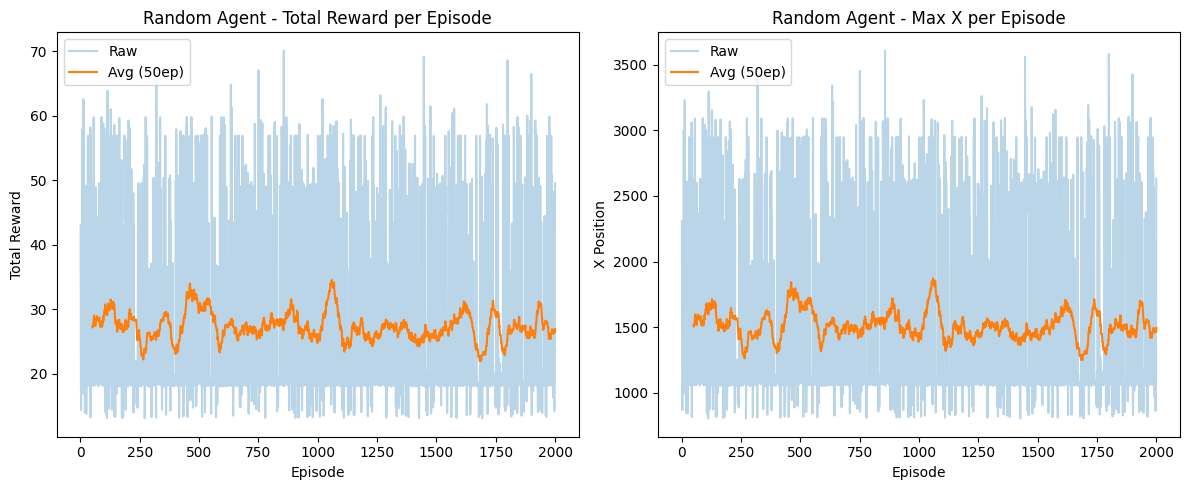

In [ ]:
import matplotlib.gridspec as gridspec

def rolling_avg(data, w):
    return np.convolve(data, np.ones(w)/w, mode='valid')

num_eps = len(random_rewards)
eps = range(1, num_eps + 1)
window = 50

fig = plt.figure(figsize=(6, 8))
gs = gridspec.GridSpec(2, 1)

ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(eps, random_rewards, alpha=0.3, label='Raw')
ax1.plot(range(window, num_eps + 1), rolling_avg(random_rewards, window), label=f'Avg ({window}ep)')
ax1.set_title('Random Agent - Total Reward per Episode')
ax1.set_xlabel('Episode')
ax1.set_ylabel('Total Reward')
ax1.legend()

ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(eps, random_max_x, alpha=0.3, label='Raw')
ax2.plot(range(window, num_eps + 1), rolling_avg(random_max_x, window), label=f'Avg ({window}ep)')
ax2.set_title('Random Agent - Max X per Episode')
ax2.set_xlabel('Episode')
ax2.set_ylabel('X Position')
ax2.legend()

plt.tight_layout()
plt.savefig('Graphs/random_baseline.png')
plt.show()


In [18]:
import re

total_rewards = []
max_x_per_ep = []

with open('Best_Run_Data.txt', 'r') as f:
    for line in f:
        match = re.search(r'Reward: ([\d.]+) \| Max X: ([\d.]+)', line)
        if match:
            total_rewards.append(float(match.group(1)))
            max_x_per_ep.append(float(match.group(2)))

print(f"Loaded {len(total_rewards)} episodes")


Loaded 2000 episodes


In [2]:
random_rewards = []
random_max_x = []

with open('random.txt', 'r') as f:
    for line in f:
        match = re.search(r'Reward: ([\d.]+) \| Max X: ([\d.]+)', line)
        if match:
            random_rewards.append(float(match.group(1)))
            random_max_x.append(float(match.group(2)))

print(f"Loaded {len(random_rewards)} episodes")


Loaded 200 episodes


In [ ]:
rainbow_rewards = []
rainbow_max_x = []
with open('poster_run.txt', 'r') as f:
    for line in f:
        match = re.search(r'Reward:\s+([\d.]+).*Max X:\s+(\d+)', line)
        if match:
            rainbow_rewards.append(float(match.group(1)))
            rainbow_max_x.append(float(match.group(2)))

print(f"Loaded {len(rainbow_rewards)} episodes")


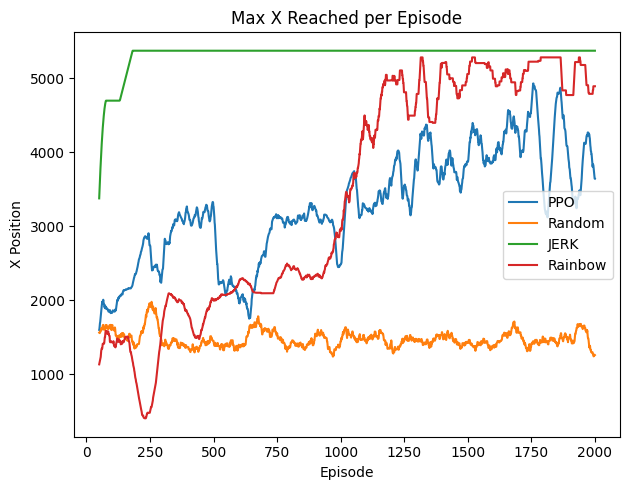

In [39]:
import re
import numpy as np
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt

# Load PPO data
total_rewards = []
max_x_per_ep = []
with open('Best_Run_Data.txt', 'r') as f:
    for line in f:
        match = re.search(r'Reward: ([\d.]+) \| Max X: ([\d.]+)', line)
        if match:
            total_rewards.append(float(match.group(1)))
            max_x_per_ep.append(float(match.group(2)))

# Load JERK data
jerk_rewards = []
jerk_max_x = []
with open('jerk_log.txt', 'r') as f:
    next(f)  # skip header
    for line in f:
        parts = line.strip().split(',')
        jerk_rewards.append(float(parts[2]))
        jerk_max_x.append(float(parts[3]))

indices = np.linspace(0, len(jerk_rewards) - 1, 2000).astype(int)
jerk_rewards = [jerk_rewards[i] for i in indices]
jerk_max_x = [jerk_max_x[i] for i in indices]

# Load Random data
random_rewards = []
random_max_x = []
with open('random.txt', 'r') as f:
    next(f)  # skip header
    for line in f:
        parts = line.strip().split(',')
        random_rewards.append(float(parts[1]))
        random_max_x.append(float(parts[2]))

# Load Rainbow data
rainbow_rewards = []
rainbow_max_x = []
with open('poster_run.txt', 'r') as f:
    for line in f:
        match = re.search(r'Reward:\s+([\d.]+).*Max X:\s+(\d+)', line)
        if match:
            rainbow_rewards.append(float(match.group(1)))
            rainbow_max_x.append(float(match.group(2)))

def rolling_avg(data, w):
    return np.convolve(data, np.ones(w)/w, mode='valid')

window = 50
ppo_eps = range(window, len(total_rewards) + 1)
rand_eps = range(window, len(random_rewards) + 1)
jerk_eps = range(window, len(jerk_rewards) + 1)
rainbow_eps = range(window, len(rainbow_rewards) + 1)

fig = plt.figure(figsize=(12, 5))
gs = gridspec.GridSpec(1, 2)

# ax1 = fig.add_subplot(gs[0, 0])
# ax1.plot(ppo_eps, rolling_avg(total_rewards, window), label='PPO')
# ax1.plot(rand_eps, rolling_avg(random_rewards, window), label='Random')
# ax1.plot(jerk_eps, rolling_avg(jerk_rewards, window), label='JERK')
# ax1.plot(rainbow_eps, rolling_avg(rainbow_rewards, window), label='Rainbow')
# ax1.set_title('Total Reward per Episode')
# ax1.set_xlabel('Episode')
# ax1.set_ylabel('Total Reward')
# ax1.legend()

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(ppo_eps, rolling_avg(max_x_per_ep, window), label='PPO')
ax2.plot(rand_eps, rolling_avg(random_max_x, window), label='Random')
ax2.plot(jerk_eps, rolling_avg(jerk_max_x, window), label='JERK')
ax2.plot(rainbow_eps, rolling_avg(rainbow_max_x, window), label='Rainbow')
ax2.set_title('Max X Reached per Episode')
ax2.set_xlabel('Episode')
ax2.set_ylabel('X Position')
ax2.legend()

plt.tight_layout()
plt.savefig('Graphs/ppo_vs_random.png')
plt.show()
